# Python Project - Customer Segmentation using RFM & Pareto Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the datasets

In [2]:
cust = pd.read_csv(r"C:\Users\mishr\Python_Sessions\Customer_Master_Data.csv")
trans = pd.read_csv(r"C:\Users\mishr\Python_Sessions\Customer_Transactions.csv")

***There are two datasets. One contains Customer data and second dataset contains Transaction history.***

## Check shape, structure and preview

In [3]:
# Show the first five rows of customer dataset
cust.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [4]:
# Number of rows and columns
cust.shape

(1000, 9)

In [5]:
# Check the data types and missing values
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [6]:
# Show the first five rows of transactions dataset
trans.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [7]:
trans.shape

(23050, 3)

In [8]:
trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23050 non-null  object 
 1   TransactionDate    23050 non-null  object 
 2   TransactionAmount  23050 non-null  float64
dtypes: float64(1), object(2)
memory usage: 540.4+ KB


**Insight :** ***JoinDate and TransactionDate have incorrect datatype.***

***These steps helps in identifying missing values, incorrect data types, and understanding the overall structure before analysis.***

## Data Cleaning

In [9]:
# Check the missing values
print(cust.isnull().sum())
print(trans.isnull().sum())

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64
CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


**Insight :** ***No any missing values found. Checking missing values helps ensure data quality. Any missing value can affect customer segmentation and business insights.***

In [10]:
# Convert JoinDate and TransactionDate columns to datetime format
cust['JoinDate'] = pd.to_datetime(cust['JoinDate'])
trans['TransactionDate'] = pd.to_datetime(trans['TransactionDate'])

C:\Users\mishr\AppData\Local\Temp\ipykernel_8944\1165323446.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trans['TransactionDate'] = pd.to_datetime(trans['TransactionDate'])


In [11]:
# Check after converting to datetime format
print(cust.info())
print(trans.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         23050 non-null  o

In [12]:
# Check the duplicate CustomerID in customer master dataset
cust['CustomerID'].duplicated().sum()

np.int64(0)

**Insight :** ***Checking for duplicate customer records helps to maintain data consistency. Unique customer records are important for accurate RFM analysis.***

In [13]:
# Ensure all transaction CustomerIDs exist in master dataset
trans['CustomerID'].isin(cust['CustomerID']).all()

np.True_

**Insight :** ***All transaction Customer IDs were validated against the master dataset. This ensures that every transaction belongs to a valid customer.***

### Join Customer_Master_Data with Customer_Transactions on CustomerID

In [14]:
df = pd.merge(trans, cust, on='CustomerID', how='left')
df.head()

,CustomerID,TransactionDate,TransactionAmount,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10771,2023-07-31,2383.07,Lakshay Dhillon,dharmajantara@gmail.com,Female,27,Ahmedabad,Widowed,3,2023-05-31
1,CUST10100,2024-03-10,497.54,Aniruddh Borah,jivikabhavsar@gmail.com,Female,53,Lucknow,Divorced,4,2022-01-08
2,CUST10031,2025-02-17,536.78,Ritvik Ahuja,jhaverifarhan@chandra.org,Male,40,Ahmedabad,Single,0,2023-12-03
3,CUST10987,2023-07-17,314.89,Jayan Wagle,ojas82@gmail.com,Not Disclosed,75,Bangalore,Widowed,4,2022-03-18
4,CUST10831,2024-12-15,2543.19,Ishita Agarwal,vbalay@yahoo.com,Not Disclosed,27,Jaipur,Divorced,4,2021-06-30


***Both the datasets combined into a single dataframe.***

## RFM Calculation

In [15]:
# Last transaction date of all the customers
lastdate = df.groupby('CustomerID')['TransactionDate'].max().reset_index().rename(columns = {'TransactionDate' : 'LastTransactionDate'})
lastdate

,CustomerID,LastTransactionDate
0,CUST10000,2025-07-17
1,CUST10001,2025-06-25
2,CUST10002,2025-07-12
3,CUST10003,2025-05-10
4,CUST10004,2025-07-22
...,...,...
995,CUST10995,2024-06-23
996,CUST10996,2025-07-15
997,CUST10997,2025-06-28
998,CUST10998,2025-03-26


In [16]:
# Next date after the last transaction date (reference date)
from datetime import timedelta

today = df['TransactionDate'].max() + timedelta(days=1)
today

Timestamp('2025-07-30 00:00:00')

In [17]:
# Recency for each customer
recency = pd.DataFrame({'CustomerID' : cust['CustomerID'], 'Recency' : today - lastdate['LastTransactionDate']})
recency

,CustomerID,Recency
0,CUST10000,13 days
1,CUST10001,35 days
2,CUST10002,18 days
3,CUST10003,81 days
4,CUST10004,8 days
...,...,...
995,CUST10995,402 days
996,CUST10996,15 days
997,CUST10997,32 days
998,CUST10998,126 days


**Insight :** ***Recency measures how recently a customer made a purchase. Customers with lower recency values are more active and engaged with the business.***

In [18]:
# Check for missing values in Recency
recency.isnull().sum()

CustomerID    0
Recency       0
dtype: int64

In [19]:
# Frequency for each customer
frequency = df.groupby('CustomerID')['TransactionDate'].count().reset_index().rename(columns = {'TransactionDate' : 'Frequency'})
frequency

,CustomerID,Frequency
0,CUST10000,23
1,CUST10001,30
2,CUST10002,24
3,CUST10003,25
4,CUST10004,19
...,...,...
995,CUST10995,21
996,CUST10996,21
997,CUST10997,20
998,CUST10998,25


**Insight :** ***Frequency shows how often a customer makes purchases. Customers with higher frequency are usually more loyal.***

In [20]:
# Monetary value for each customer
monetary = df.groupby('CustomerID')['TransactionAmount'].sum().reset_index().rename(columns = {'TransactionAmount' : 'Monetary'})
monetary

,CustomerID,Monetary
0,CUST10000,21265.49
1,CUST10001,28654.31
2,CUST10002,23884.03
3,CUST10003,24206.03
4,CUST10004,25565.30
...,...,...
995,CUST10995,24325.19
996,CUST10996,21809.11
997,CUST10997,21120.48
998,CUST10998,29494.56


**Insight :** ***Monetary value represents the total amount spent by customers. Customers with higher monetary values contribute more revenue to the business.***

### Creating RFM table

In [21]:
# Store result in a new DataFrame called df_rfm
df_rfm = pd.merge(recency, frequency, on='CustomerID', how='left')
df_rfm = pd.merge(df_rfm, monetary, on='CustomerID', how='left')
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13 days,23,21265.49
1,CUST10001,35 days,30,28654.31
2,CUST10002,18 days,24,23884.03
3,CUST10003,81 days,25,24206.03
4,CUST10004,8 days,19,25565.30


### Score RFM based on Quantiles

In [22]:
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5,4,3,2,1])
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'], 5, labels=[1,2,3,4,5])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 5, labels=[1,2,3,4,5])

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,CUST10000,13 days,23,21265.49,4,3,2
1,CUST10001,35 days,30,28654.31,3,5,5
2,CUST10002,18 days,24,23884.03,4,3,3
3,CUST10003,81 days,25,24206.03,1,4,3
4,CUST10004,8 days,19,25565.30,5,1,4


***Customers were scored from 1 to 5 based on their RFM values. Higher scores indicate better customer engagement.***

### Combined RFM Segment

In [23]:
# Concatenating the RFM scores
df_rfm['RFM_Segment'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment
0,CUST10000,13 days,23,21265.49,4,3,2,432
1,CUST10001,35 days,30,28654.31,3,5,5,355
2,CUST10002,18 days,24,23884.03,4,3,3,433
3,CUST10003,81 days,25,24206.03,1,4,3,143
4,CUST10004,8 days,19,25565.30,5,1,4,514


**Insight :** ***RFM scores were combined into a single segment code. This helps in identifying customer behaviour patterns quickly.***

### Assign Segment Labels

In [24]:
df_rfm['Segment_Labels'] = 'Others'
df_rfm.loc[df_rfm['RFM_Segment'] == '555', 'Segment_Labels'] = 'Champions'
df_rfm.loc[df_rfm['RFM_Segment'] == '111', 'Segment_Labels'] = 'Lost'
df_rfm.loc[(df_rfm['RFM_Segment'].str[0] == '5') & (df_rfm['RFM_Segment'] != '555'), 'Segment_Labels'] = 'Recent'
df_rfm.loc[(df_rfm['RFM_Segment'].str[1] == '5') & (df_rfm['RFM_Segment'] != '555'), 'Segment_Labels'] = 'Frequent'
df_rfm.loc[(df_rfm['RFM_Segment'].str[2] == '5') & (df_rfm['RFM_Segment'] != '555'), 'Segment_Labels'] = 'Big Spenders'

In [25]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment_Labels
0,CUST10000,13 days,23,21265.49,4,3,2,432,Others
1,CUST10001,35 days,30,28654.31,3,5,5,355,Big Spenders
2,CUST10002,18 days,24,23884.03,4,3,3,433,Others
3,CUST10003,81 days,25,24206.03,1,4,3,143,Others
4,CUST10004,8 days,19,25565.30,5,1,4,514,Recent


**Insight :** ***Customers were grouped into the segments such as Champions, Lost and Recent. This segmentation can help businesses create targeted marketing strategies.***

In [26]:
# Distribution of customers across the segments
df_rfm['Segment_Labels'].value_counts()

Segment_Labels
Others          543
Big Spenders    165
Recent          160
Frequent         63
Champions        35
Lost             34
Name: count, dtype: int64

In [27]:
df_rfm[df_rfm['Segment_Labels'] == 'Champions'].head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment_Labels
6,CUST10006,11 days,28,27922.36,5,5,5,555,Champions
46,CUST10046,11 days,30,30458.69,5,5,5,555,Champions
131,CUST10131,5 days,30,32229.50,5,5,5,555,Champions
144,CUST10144,3 days,31,28005.14,5,5,5,555,Champions
174,CUST10174,1 days,29,29017.00,5,5,5,555,Champions


**Insight :** ***Champions customers are highly valuable because they purchase frequently, spend more and have recently engaged with the business.***

In [28]:
df_rfm[df_rfm['Segment_Labels'] == 'Lost'].head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment_Labels
7,CUST10007,86 days,15,14957.06,1,1,1,111,Lost
65,CUST10065,104 days,13,15173.99,1,1,1,111,Lost
77,CUST10077,145 days,13,15500.23,1,1,1,111,Lost
80,CUST10080,162 days,14,15268.83,1,1,1,111,Lost
91,CUST10091,101 days,16,14476.47,1,1,1,111,Lost


**Insight :** ***Lost customers have not interacted with the business for a long time. These customers may require re-engagement campaigns or personalized offers.***

In [29]:
df_rfm[df_rfm['Segment_Labels'] == 'Recent'].head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,Segment_Labels
4,CUST10004,8 days,19,25565.30,5,1,4,514,Recent
8,CUST10008,3 days,19,19479.25,5,1,2,512,Recent
9,CUST10009,7 days,25,22832.83,5,4,3,543,Recent
15,CUST10015,6 days,20,26315.71,5,2,4,524,Recent
16,CUST10016,4 days,24,24607.24,5,3,4,534,Recent


**Insight :** ***Recent customers can potentially become loyal customers if engaged properly.***

## Visualizations

C:\Users\mishr\AppData\Local\Temp\ipykernel_8944\1976306322.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment_Labels', data=df_rfm, palette='Set1')


Text(0, 0.5, 'Count')

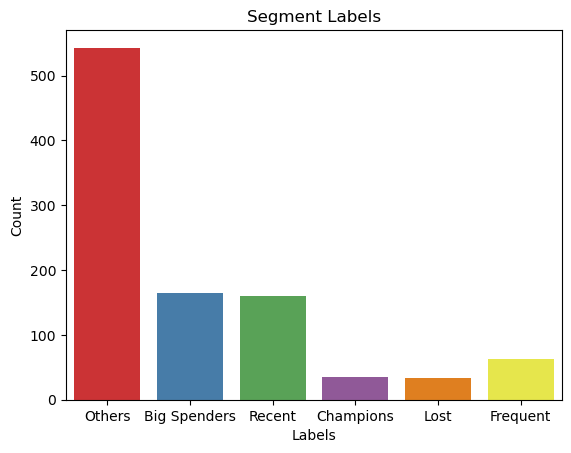

In [30]:
# Count of customers in each segment
sns.countplot(x='Segment_Labels', data=df_rfm, palette='Set1')
plt.title('Segment Labels')
plt.xlabel('Labels')
plt.ylabel('Count')

**Insight :** ***The segment count plot provides a clear understanding of customer distribution across the segments. It helps identify the different customer groups.***

In [31]:
# Revenue contribution by segment
# Calculation :
seg_revenue = df_rfm.groupby('Segment_Labels')['Monetary'].sum().reset_index()
seg_revenue = seg_revenue.sort_values('Monetary', ascending=False).reset_index(drop=True)
seg_revenue

,Segment_Labels,Monetary
0,Others,11314090.88
1,Big Spenders,5131769.50
2,Recent,3385389.30
3,Frequent,1598110.10
4,Champions,1099393.85
5,Lost,524446.03


([<matplotlib.patches.Wedge at 0x161b562ef90>,
 [Text(0.03185122564103357, 1.0995387666768117, 'Others'),
  Text(-0.8813739954272001, -0.6581640222503006, 'Big Spenders'),
  Text(0.25216984054770797, -1.0707055484670582, 'Recent'),
  Text(0.8687462429283428, -0.6747443704084451, 'Frequent'),
  Text(1.2446865819673893, -0.3751737099935683, 'Champions'),
  Text(1.0971918853242217, -0.07854913607850643, 'Lost')],
 [Text(0.017373395804200126, 0.5997484181873517, '49.1%'),
  Text(-0.4807494520512, -0.35899855759107296, '22.3%'),
  Text(0.13754718575329522, -0.5840212082547589, '14.7%'),
  Text(0.4738615870518233, -0.36804238385915183, '6.9%'),
  Text(0.7659609735183932, -0.23087612922681122, '4.8%'),
  Text(0.5984683010859391, -0.04284498331554896, '2.3%')])

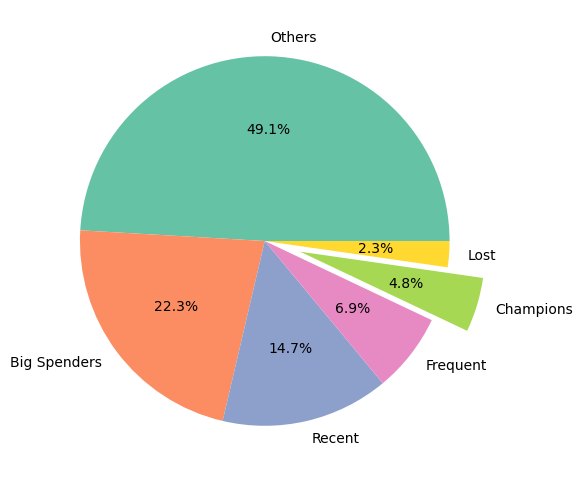

In [32]:
# Pie Chart
plt.figure(figsize=(6,6))
explode = [0,0,0,0,0.2,0]
plt.pie(seg_revenue['Monetary'], labels = seg_revenue['Segment_Labels'], 
        autopct = '%0.1f%%', explode = explode, colors = sns.color_palette('Set2'))

**Insight :** ***Revenue contribution shows which customer segments generate the highest business revenue.***

Text(0.5, 1.0, 'Recency vs Monetary')

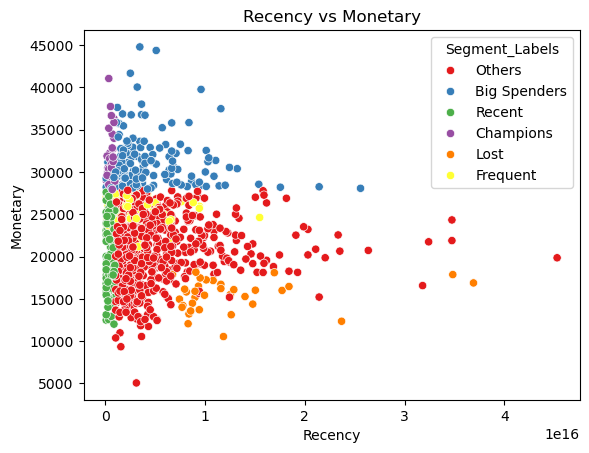

In [33]:
# Recency vs Monetary scatter plot
sns.scatterplot(x = 'Recency', y = 'Monetary', data = df_rfm, hue = 'Segment_Labels', palette = 'Set1')
plt.title('Recency vs Monetary')

**Insight :** ***The scatter plot highlights the relationship between customer activity and spending behaviour. Customers with low recency and high monetary value are the most valuable customers.***

## Pareto Analysis: Show how top 20% customers contribute to 80% revenue

In [34]:
df = df_rfm[['CustomerID', 'Monetary']]
df

,CustomerID,Monetary
0,CUST10000,21265.49
1,CUST10001,28654.31
2,CUST10002,23884.03
3,CUST10003,24206.03
4,CUST10004,25565.30
...,...,...
995,CUST10995,24325.19
996,CUST10996,21809.11
997,CUST10997,21120.48
998,CUST10998,29494.56


In [35]:
# Step 1 : Sort customers by revenue in descending order
df = df.sort_values(by = 'Monetary', ascending=False)
df

,CustomerID,Monetary
944,CUST10944,44784.99
510,CUST10510,44367.33
53,CUST10053,41674.56
776,CUST10776,41050.76
696,CUST10696,40035.48
...,...,...
888,CUST10888,10537.46
751,CUST10751,10536.13
973,CUST10973,10375.62
278,CUST10278,9333.33


**Insight :** ***Customers were sorted based on the monetary value to identify the highest revenue generating customers.***

In [36]:
# Step 2 : Calculate cumulative revenue
df['Cumulative_Revenue'] = df['Monetary'].cumsum()
df

,CustomerID,Monetary,Cumulative_Revenue
944,CUST10944,44784.99,44784.99
510,CUST10510,44367.33,89152.32
53,CUST10053,41674.56,130826.88
776,CUST10776,41050.76,171877.64
696,CUST10696,40035.48,211913.12
...,...,...,...
888,CUST10888,10537.46,23017901.89
751,CUST10751,10536.13,23028438.02
973,CUST10973,10375.62,23038813.64
278,CUST10278,9333.33,23048146.97


**Insight :** ***Cumulative revenue helps track how total revenue increases as more customers are added.***

In [37]:
# Step 3 : Calculate revenue percentage
df['Revenue_Percent'] = df['Cumulative_Revenue']/df['Monetary'].sum()*100
df.head()

,CustomerID,Monetary,Cumulative_Revenue,Revenue_Percent
944,CUST10944,44784.99,44784.99,0.194268
510,CUST10510,44367.33,89152.32,0.386724
53,CUST10053,41674.56,130826.88,0.567500
776,CUST10776,41050.76,171877.64,0.745570
696,CUST10696,40035.48,211913.12,0.919235


**Insight :** ***Revenue percentage shows the share of total revenue contributed by customers cumulatively.***

In [38]:
# Step 4 : Reset the index
df = df.reset_index(drop=True)
df.head()

,CustomerID,Monetary,Cumulative_Revenue,Revenue_Percent
0,CUST10944,44784.99,44784.99,0.194268
1,CUST10510,44367.33,89152.32,0.386724
2,CUST10053,41674.56,130826.88,0.567500
3,CUST10776,41050.76,171877.64,0.745570
4,CUST10696,40035.48,211913.12,0.919235


In [39]:
# Step 5 : Calculate the customer percentage
df['Customer_Percent'] = (df.index+1)/len(df)*100
df.head()

,CustomerID,Monetary,Cumulative_Revenue,Revenue_Percent,Customer_Percent
0,CUST10944,44784.99,44784.99,0.194268,0.1
1,CUST10510,44367.33,89152.32,0.386724,0.2
2,CUST10053,41674.56,130826.88,0.567500,0.3
3,CUST10776,41050.76,171877.64,0.745570,0.4
4,CUST10696,40035.48,211913.12,0.919235,0.5


In [40]:
# Step 6 : Identify the values where customer percent is around 20% and revenue is around 80%
df[df['Customer_Percent'] <= 20].tail(1)

,CustomerID,Monetary,Cumulative_Revenue,Revenue_Percent,Customer_Percent
199,CUST10338,27838.98,6231163.35,27.029495,20.0


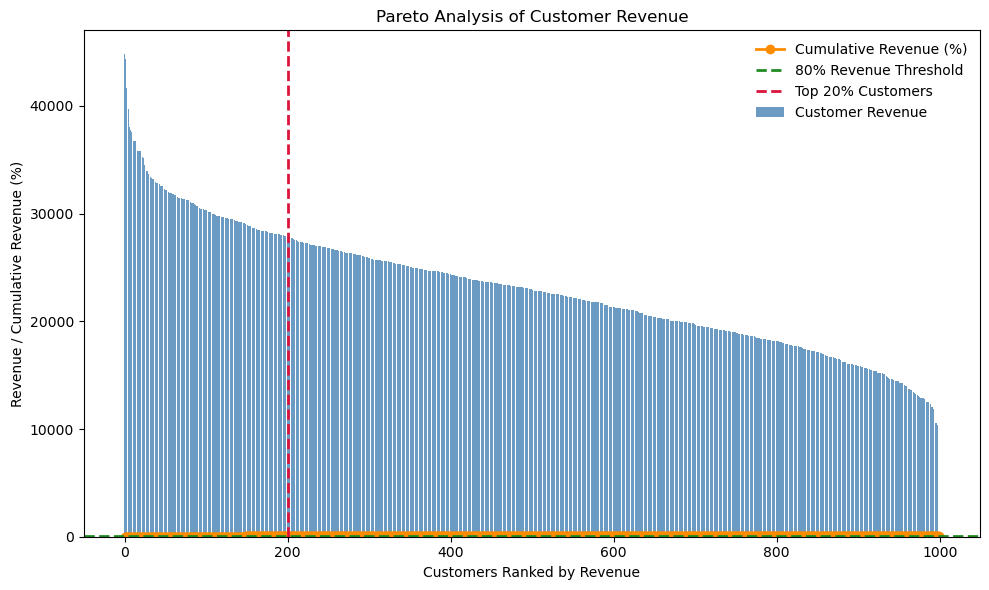

In [48]:
# Bar plot for each customer revenue
plt.figure(figsize=(10,6))
plt.bar(df.index, df['Monetary'], color='steelblue', alpha=0.8, label='Customer Revenue')

# Line plot for cumulative revenue %
plt.plot(df.index, df['Revenue_Percent'], color='darkorange', marker='o', linewidth=2, label='Cumulative Revenue (%)')

# Highlight 80% revenue line
plt.axhline(80, color='forestgreen', linestyle='--', linewidth=2, label='80% Revenue Threshold')

# Highlight 20% customer cutoff
cutoff = int(0.2 * len(df))
plt.axvline(cutoff, color='crimson', linestyle='--', linewidth=2, label='Top 20% Customers')

plt.title('Pareto Analysis of Customer Revenue')
plt.xlabel('Customers Ranked by Revenue')
plt.ylabel('Revenue / Cumulative Revenue (%)')
plt.legend(frameon=False)
plt.tight_layout()

**Insight :** ***The Pareto analysis reveals that the top 20% of customers contributed approximately 27% of the total revenue, suggesting a relatively balanced revenue distribution across the customer base rather than a heavy dependence on a small group of customers. This indicates stable customer engagement with the business and reduced revenue concentration risk.***

***The highest spending customer generated more than ₹44,000 in revenue, highlighting the strong impact of premium customers on overall sales performance and the importance of targeted retention and loyalty strategies for high-value buyers.***